# Learning Rate Plot

This file is intended to plot the loss curve of the two tests performed over 10000 epochs. One with a LR of 1e-4 and one with a LR of 1e-5. The plot will be used in the report to show the difference in convergence between the two learning rates. The plot will also be used to show the stability of the training process. 

In [8]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd

# extract tensorboard logs
log_path_1 = "/media/aris/Data/master2025dev/aris_master/training/03-17_Default_Constant_LR/logs/training/events.out.tfevents.1773931761.aris-pc.3207580.0"
log_path_2 = "/media/aris/Data/master2025dev/aris_master/training/03-17_Default_Constant_LR_Low_LR/logs/training/events.out.tfevents.1774138296.aris-pc.1836599.0"

from tensorflow.python.summary.summary_iterator import summary_iterator

loss1 = []
for summary in summary_iterator(log_path_1):
    if summary.step % 10000 == 0:  # Print every 100 steps
        print(f"Step: {summary.step}")
    for value in summary.summary.value:
        if value.tag == "loss":
            loss1.append((summary.step, value.simple_value))
            # print(f"Loss: {value.simple_value}")
loss2 = []
for summary in summary_iterator(log_path_2):
    if summary.step % 10000 == 0:  # Print every 100 steps
        print(f"Step: {summary.step}")
    for value in summary.summary.value:
        if value.tag == "loss":
            loss2.append((summary.step, value.simple_value))


Step: 0
Step: 10000
Step: 10000
Step: 10000
Step: 10000
Step: 10000
Step: 20000
Step: 20000
Step: 20000
Step: 20000
Step: 20000
Step: 30000
Step: 30000
Step: 30000
Step: 30000
Step: 30000
Step: 40000
Step: 40000
Step: 40000
Step: 40000
Step: 40000
Step: 50000
Step: 50000
Step: 50000
Step: 50000
Step: 50000
Step: 60000
Step: 60000
Step: 60000
Step: 60000
Step: 60000
Step: 70000
Step: 70000
Step: 70000
Step: 70000
Step: 70000
Step: 80000
Step: 80000
Step: 80000
Step: 80000
Step: 80000
Step: 90000
Step: 90000
Step: 90000
Step: 90000
Step: 90000
Step: 100000
Step: 100000
Step: 100000
Step: 100000
Step: 100000
Step: 110000
Step: 110000
Step: 110000
Step: 110000
Step: 110000
Step: 120000
Step: 120000
Step: 120000
Step: 120000
Step: 120000
Step: 130000
Step: 130000
Step: 130000
Step: 130000
Step: 130000
Step: 140000
Step: 140000
Step: 140000
Step: 140000
Step: 140000
Step: 150000
Step: 150000
Step: 150000
Step: 150000
Step: 150000
Step: 160000
Step: 160000
Step: 160000
Step: 160000
Step: 1600

475000 480000


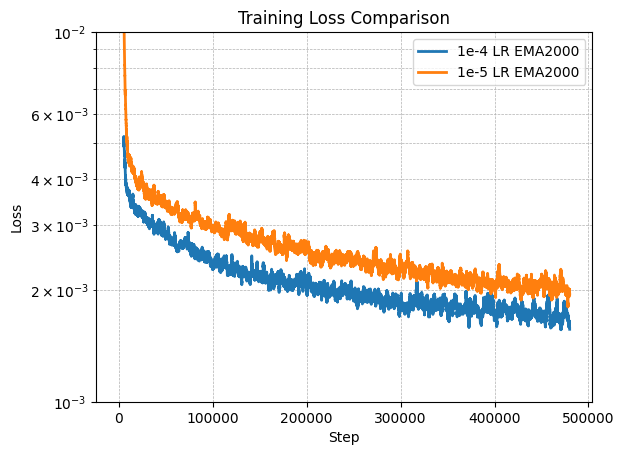

In [9]:
#Plot the two loss curves:
import matplotlib as mpl
import matplotlib.pyplot as plt

# # Use LaTeX for all text rendering
# mpl.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],  # LaTeX default look
#     "axes.unicode_minus": False,
# })

print(len(loss1), len(loss2))

steps1, values1 = zip(*loss1)
steps2, values2 = zip(*loss2)

# exponential moving averages
window = 2000
ma_values1 = pd.Series(values1).ewm(span=window, adjust=False).mean().values
ma_values2 = pd.Series(values2).ewm(span=window, adjust=False).mean().values


# plt.plot(steps1, values1, label="Default Constant LR")
# plt.plot(steps2, values2, label="Default Constant LR Low LR")
# plot smoothed curves


plt.plot(steps1, ma_values1, label=f"1e-4 LR EMA{window}", linewidth=2)
plt.plot(steps2, ma_values2, label=f"1e-5 LR EMA{window}", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.yscale('log')
plt.ylim(1e-3, 1e-2)  # Adjust y-axis limits for better visibility
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.show()



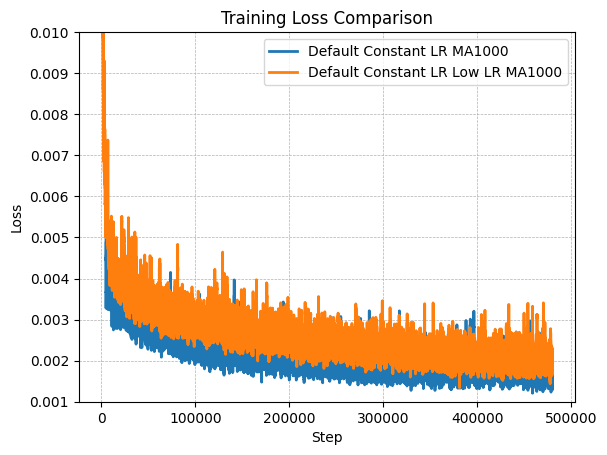

In [29]:

#Tensor Board's EMA implementation for smoothing curves
import math
def smooth(scalars: list[float], weight: float) -> list[float]:
    """
    EMA implementation according to
    https://github.com/tensorflow/tensorboard/blob/34877f15153e1a2087316b9952c931807a122aa7/tensorboard/components/vz_line_chart2/line-chart.ts#L699
    """
    last = 0
    smoothed = []
    num_acc = 0
    for next_val in scalars:
        last = last * weight + (1 - weight) * next_val
        num_acc += 1
        # de-bias
        debias_weight = 1
        if weight != 1:
            debias_weight = 1 - math.pow(weight, num_acc)
        smoothed_val = last / debias_weight
        smoothed.append(smoothed_val)

    return smoothed


ma_values1 = smooth(values1, weight=0.99)
ma_values2 = smooth(values2, weight=0.99)

plt.plot(steps1, ma_values1, label=f"Default Constant LR MA{window}", linewidth=2)
plt.plot(steps2, ma_values2, label=f"Default Constant LR Low LR MA{window}", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
# plt.yscale('log')
plt.ylim(1e-3, 1e-2)  # Adjust y-axis limits for better visibility
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.show()


